# DL vertex finding network training

This notebook is designed to take the input and truth images generated by the <code>make_images.ipynb</code> notebook and train networks for vertex finding. This notebook generates models for each of the U, V and W views for each of the required passes.
    
Most of the cells below will not need any editing, but towards the bottom of the notebook you will find some additional markdown that describes what you may need to edit (essentially just some file locations).

In [28]:
# Automatically reload external libraries that change
%reload_ext autoreload
%autoreload 2

# If a matplotlib plot command is issued, display the results in the notebook
%matplotlib inline

In [ ]:
from network import set_seed, get_class_weights
from network import load_model_only, load_model, save_model, create_model
from network import accuracy

from data import SegmentationDataset, SegmentationBunch


In [31]:
import os


In [32]:
!python --version

Python 3.10.20


In [34]:
!/usr/bin/env python3 -c "import sys; print(sys.executable)"

/opt/conda/bin/python3


# Run network training here

The key parameters that will need editing are the view and the pass to be trained. Each view/pass combination has its own network. Views are specified using the standard U, V, W nomenclature (and is consistent with the file naming conventions from previous steps), while the pass is either pass 1 or pass 2.

The respective variables can be set in the cell below via <code>view</code> and <code>vertex_pass</code>.

If you edited the <code>thresholds</code> variable at the <code>make_images</code> stage, you may need to update the <code>NUM_CLASSES</code> variable to reflect any change in the number of thresholds. Note that this value should be equal to the length of the <code>thresholds</code> variable, despite this variable specifying bin edges, because one extra class is required to represent the null case where a pixel has no hits in it.

<code>batch_size</code> can, of course, be varied according to the available resources of your GPU, but as a semantic segmentation network you'll need a lot of memory on your GPU to increase this beyond the current default of 32.

The <code>image_path</code> variable should contain the path to the images generated by the <code>make_images</code> notebook (i.e. <code>global_path</code>), and will expect to find the <code>Hits</code> and <code>Truth</code> folders within that path).

> Note that the code has been updated to allow for sample balancing: taking as input the `balance_map` dictionary, it can, for each sample class, consider a different fraction.
> The dict. is required to follow this schema
> ```python
> {
>   'class_1': {'dir': 'path_1', 'fraction': 0.75},
>   'class_2': {'dir': 'path_2', 'fraction': 0.25}
> }
> ```

Note that the cells below will count the class representation in the training set, determine how to weight them and print this out. It's worth taking a look at this output to ensure all classes are represented, as training will fail if they are not.

You will want to set the number of epochs, <code>n_epochs</code> to train for. This is not easy to determine a priori, but 20 is a reasonable starting point (plots of the loss function and accuracy are produced to help you determine when the network has effectively trained).

<code>model_name</code> acts as a prefix for saving the model. The state of the model is saved after every epoch, with a suffix indicating the epoch number.

Once you are happy with the variable values you can run all of the cells in this section in order (having run all of the cells above), with the final cell in this section actually performing the training.

# First training: perfectly balanced 50-50/50-50 samples

In [8]:
# This line is important for GPU running, otherwise some weights end up on the CPU
torch.set_default_tensor_type(torch.cuda.FloatTensor)

view = "W"
vertex_pass = 1
the_seed = 42
gpu = torch.device('cuda:0')
batch_size=150
NUM_CLASSES = 20   # NULL = 0, various distance bands 1-19
# image_path = f"Accel/Pass{vertex_pass}/Images{view}"
# image_path = '/exp/icarus/data/users/msotgia/vertexStudies/forTraining/ICARUS_DlVertex'
image_path = '/home/msotgia/vertexOnEaf/ICARUS_DlVertex_HDF5' # For processing on EAF w/o overhead

balance_map = {
    'numi_numu': {'dir': f'NuMI/numu/Pass{vertex_pass}/Images{view}', 'fraction': 0.25},
    'numi_nue':  {'dir': f'NuMI/nue/Pass{vertex_pass}/Images{view}',  'fraction': 0.25},
    'bnb_numu':  {'dir': f'BNB/numu/Pass{vertex_pass}/Images{view}',  'fraction': 0.25},
    'bnb_nue':   {'dir': f'BNB/nue/Pass{vertex_pass}/Images{view}',   'fraction': 0.25}
}

n_epochs = 20
model_name = "icarus_pass1_fully_balanced_beam_flavour"

for subdir in ["models", "stats", "images"]:
    dir = f"outputs/{subdir}/pass{vertex_pass}/{view}"
    if not os.path.exists(dir):
        os.makedirs(dir)

In [9]:
# main.py

#from data import *
#from network import *

set_seed(the_seed)
bunch = SegmentationBunch(image_path, balance_map, batch_size=batch_size, valid_pct = 0.25, device=gpu)
train_stats = bunch.count_classes(NUM_CLASSES)
weights = get_class_weights(train_stats)

device=cuda:0 was set: forcing num_workers=0, shuffle_training=False and pin_memory=False (was 8) since CUDA tensors can't cross process boundaries


Reading class sizes:   0%|          | 0/4 [00:00<?, ?it/s]

Sampling classes:   0%|          | 0/4 [00:00<?, ?it/s]

Counting classes:   0%|          | 0/4 [00:00<?, ?it/s]

Counting for batch:   0%|          | 0/5 [00:00<?, ?it/s]

Counting for batch:   0%|          | 0/5 [00:00<?, ?it/s]

Counting for batch:   0%|          | 0/5 [00:00<?, ?it/s]

Counting for batch:   0%|          | 0/5 [00:00<?, ?it/s]

`weights` before the changes were

```python
[np.float64(8.623750719476234e-08),
 np.float64(0.007172987689688895),
 np.float64(0.0007584045062301771),
 np.float64(0.00037038372234998225),
 np.float64(0.00024288647877137123),
 np.float64(0.000198978541093642),
 np.float64(0.00019057576343509776),
 np.float64(0.0001858506259661026),
 np.float64(0.0003745255916270518),
 np.float64(0.000288019790190076),
 np.float64(0.00048425659795097424),
 np.float64(0.0007499850008340051),
 np.float64(0.001114525094378949),
 np.float64(0.0016114242089710934),
 np.float64(0.0016443771616277915),
 np.float64(0.002822851947461105),
 np.float64(0.004856441516708472),
 np.float64(0.011101357805652648),
 np.float64(0.08215330262912612),
 np.float64(0.8836787790904292)]
 ```

 Below is after 

In [22]:
weights

[np.float64(8.595516395945997e-08),
 np.float64(0.007149999886758128),
 np.float64(0.0007567358460601457),
 np.float64(0.00036953976715953436),
 np.float64(0.00024207916886665677),
 np.float64(0.0001981138621505619),
 np.float64(0.00018945002017485001),
 np.float64(0.00018460452360552428),
 np.float64(0.00037189264827564483),
 np.float64(0.00028662952400715743),
 np.float64(0.0004818363438897145),
 np.float64(0.0007500658953065594),
 np.float64(0.0011114845160855623),
 np.float64(0.0015977414403884741),
 np.float64(0.0016308937968408056),
 np.float64(0.00281466752813729),
 np.float64(0.004839165842035388),
 np.float64(0.011074782014265799),
 np.float64(0.08162353038723805),
 np.float64(0.8843267010335901)]

In [11]:
np.savez(f'outputs/stats/pass{vertex_pass}/{view}/weights_{model_name}.npz', weights)

In [12]:
train_losses = torch.zeros(n_epochs * len(bunch.train_dl), device=gpu)
val_losses = torch.zeros(n_epochs, device=gpu)
batch_losses = torch.zeros(len(bunch.valid_dl), device=gpu)

train_accs = torch.zeros(n_epochs * len(bunch.train_dl), device=gpu)
val_accs = torch.zeros(n_epochs, device=gpu)
batch_accs = torch.zeros(len(bunch.valid_dl), device=gpu)

In [13]:
# Standard model creation
model, loss_fn, optim = create_model(NUM_CLASSES, weights, gpu)

i = 0
start = 0
finish = n_epochs

In [ ]:
from tqdm.notebook import tqdm
set_seed(the_seed)
for e in tqdm(range(start, finish), desc='Training'):
    model = model.train()
    n_batches = len(bunch.train_dl)
    for b, batch in enumerate(tqdm(bunch.train_dl, desc=f'For epoch {e}, training over batches')):
        x, y = batch
        pred = model.forward(x)
        loss = loss_fn(pred, y)

        train_losses[i] = loss.item()
        train_accs[i] = accuracy(pred, y, nearby=False)

        loss.backward()
        optim.step()
        #scheduler.step()
        optim.zero_grad()
        i += 1
        if b == (n_batches - 1):
            save_model(model, x, f"outputs/models/pass{vertex_pass}/{view}/{model_name}_{e}")

    # Validate
    model = model.eval()
    with torch.no_grad():
        for b, batch in enumerate(tqdm(bunch.valid_dl, desc=f'For epoch {e}, validating over batches')):
            x, y = batch
            pred = model.forward(x)
            loss = loss_fn(pred, y)
            
            batch_losses[b] = loss.item()
            batch_accs[b] = accuracy(pred, y, nearby=False)
        val_losses[e] = torch.mean(batch_losses)
        val_accs[e] = torch.mean(batch_accs)

    np.savez(f'outputs/stats/pass{vertex_pass}/{view}/losses_{model_name}_{e}.npz', 
             train_losses.cpu(), val_losses.cpu(), batch_losses.cpu(), train_accs.cpu(), val_accs.cpu(), batch_accs.cpu())

    

Training:   0%|          | 0/20 [00:00<?, ?it/s]

For epoch 0, training over batches:   0%|          | 0/2387 [00:00<?, ?it/s]

For epoch 0, validating over batches:   0%|          | 0/795 [00:00<?, ?it/s]

For epoch 1, training over batches:   0%|          | 0/2387 [00:00<?, ?it/s]

For epoch 2, training over batches:   0%|          | 0/2387 [00:00<?, ?it/s]

# Assess network performance

Having trained a network, you can look at its performance - this should be run immediately after the network has finished training. The cells below should not require any editing.

The first cell runs over a single batch from the validation set and produuces images allowing you to compare the truth (left image) to the network classification (right image), though it is worth noting that the <code>show_batch</code> function produces all images in the same folder and does not uniquely identify the view or pass, so if you want to retain them, you'll want to move them between runs.

The next three cells produce plots showing the evolution of the network across epochs. Ideally you want to see a plateauing of the loss and accuracy to establish a well trained model, with no evidence that the training and validation performance are diverging (you can always select a model from an earlier epoch before divergence if the network appears to be overfitting - or get more training samples if the network is not adequately trained).

The final cell in this section simply saves the evolution history of the network to allow easy plot regenertion if needed.

In [23]:
set_seed(the_seed)
model = model.eval()
with torch.no_grad():
    for b, batch in enumerate(bunch.valid_dl):
        x, y = batch
        pred = model.forward(x)
        show_batch(finish, b, x, pred, y, n=32, randomize=False)
        break

In [24]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 32
mpl.rcParams['axes.labelsize'] = 32
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['ytick.labelsize'] = 22
mpl.rcParams['legend.fontsize'] = 24

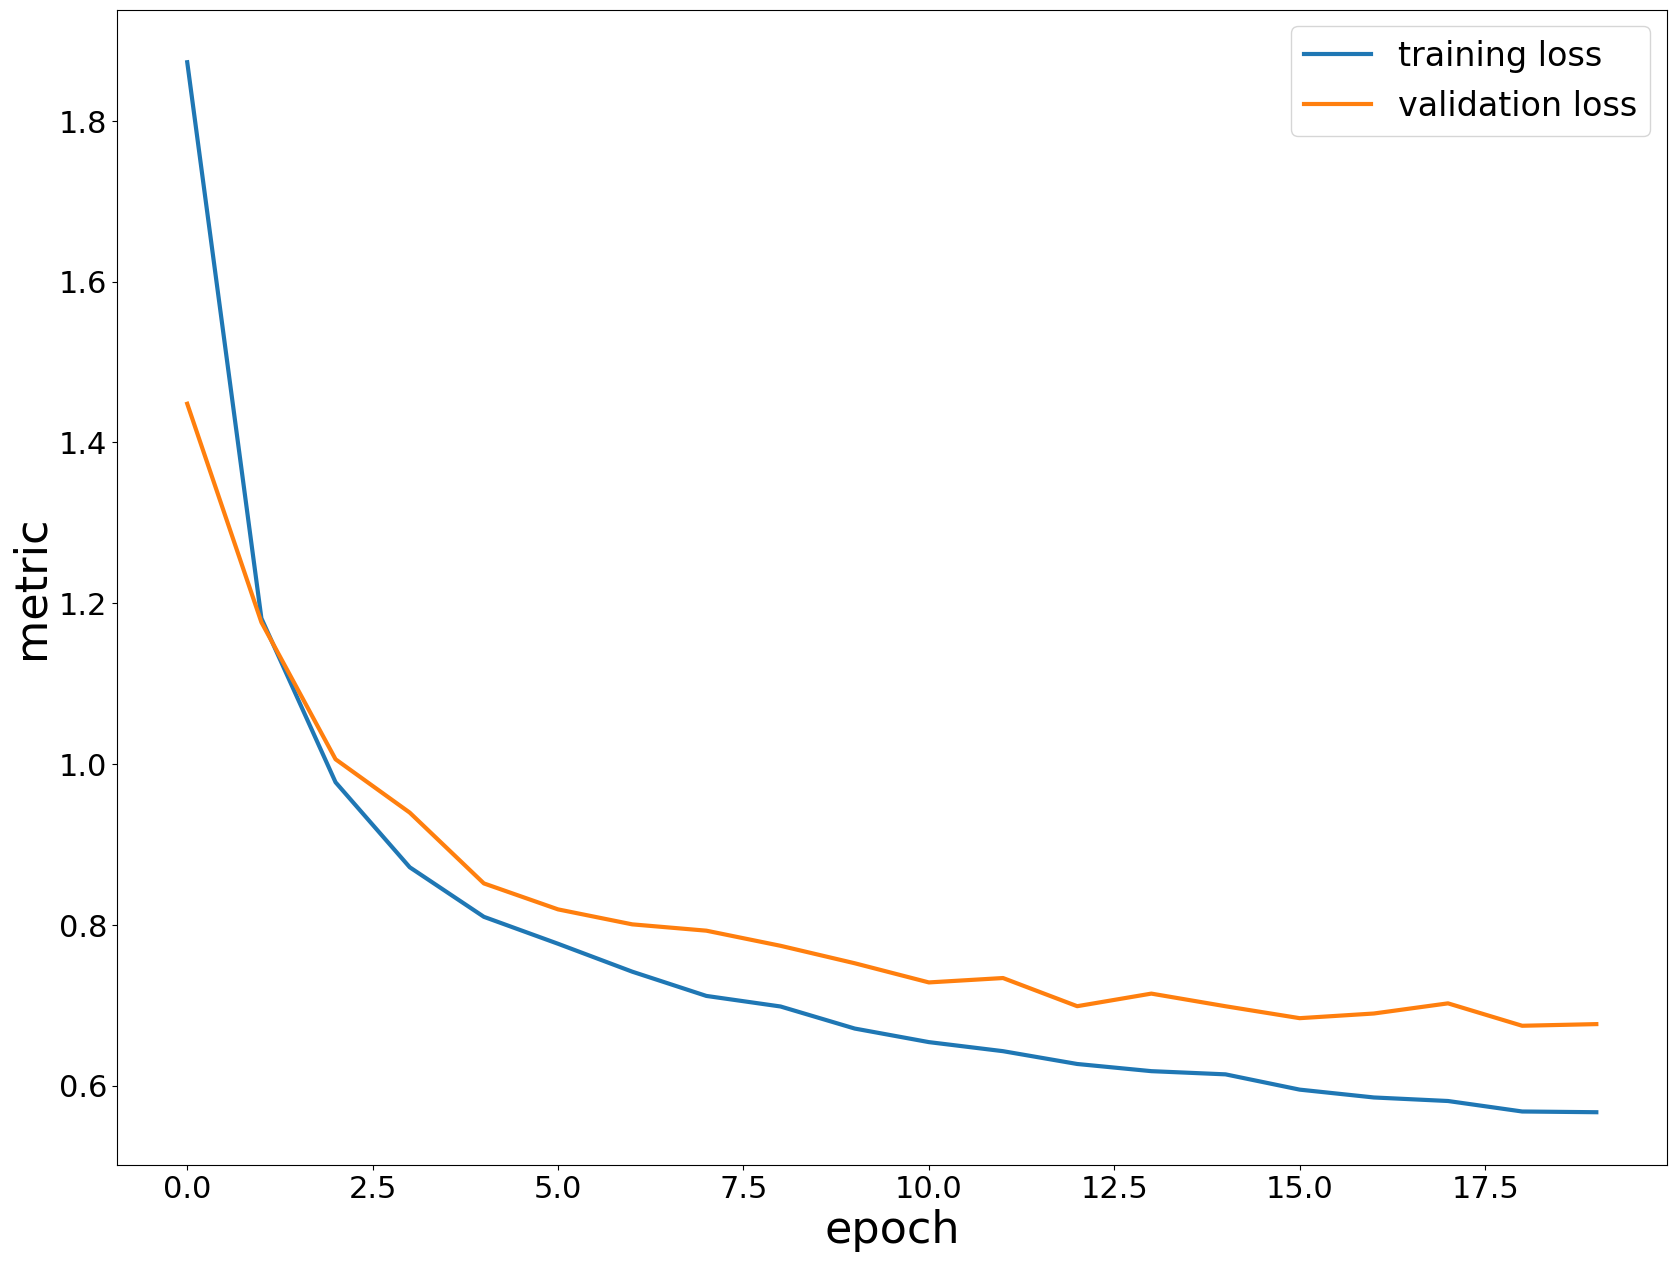

In [25]:
fig = plt.figure(figsize=(20, 15))
plt.xlabel('epoch')
plt.ylabel('metric')

tl = torch.mean(train_losses.reshape([n_epochs, -1]), axis=1).detach().cpu()
vl = val_losses.detach().cpu()
plt.plot(tl, label="training loss")
plt.plot(vl, label="validation loss")

plt.legend()

fig.savefig(f"outputs/stats/pass{vertex_pass}/{view}/stats_loss_{vertex_pass}_{view}.pdf", dpi=200)
fig.savefig(f"outputs/stats/pass{vertex_pass}/{view}/stats_loss_{vertex_pass}_{view}.png", dpi=200, facecolor='w')

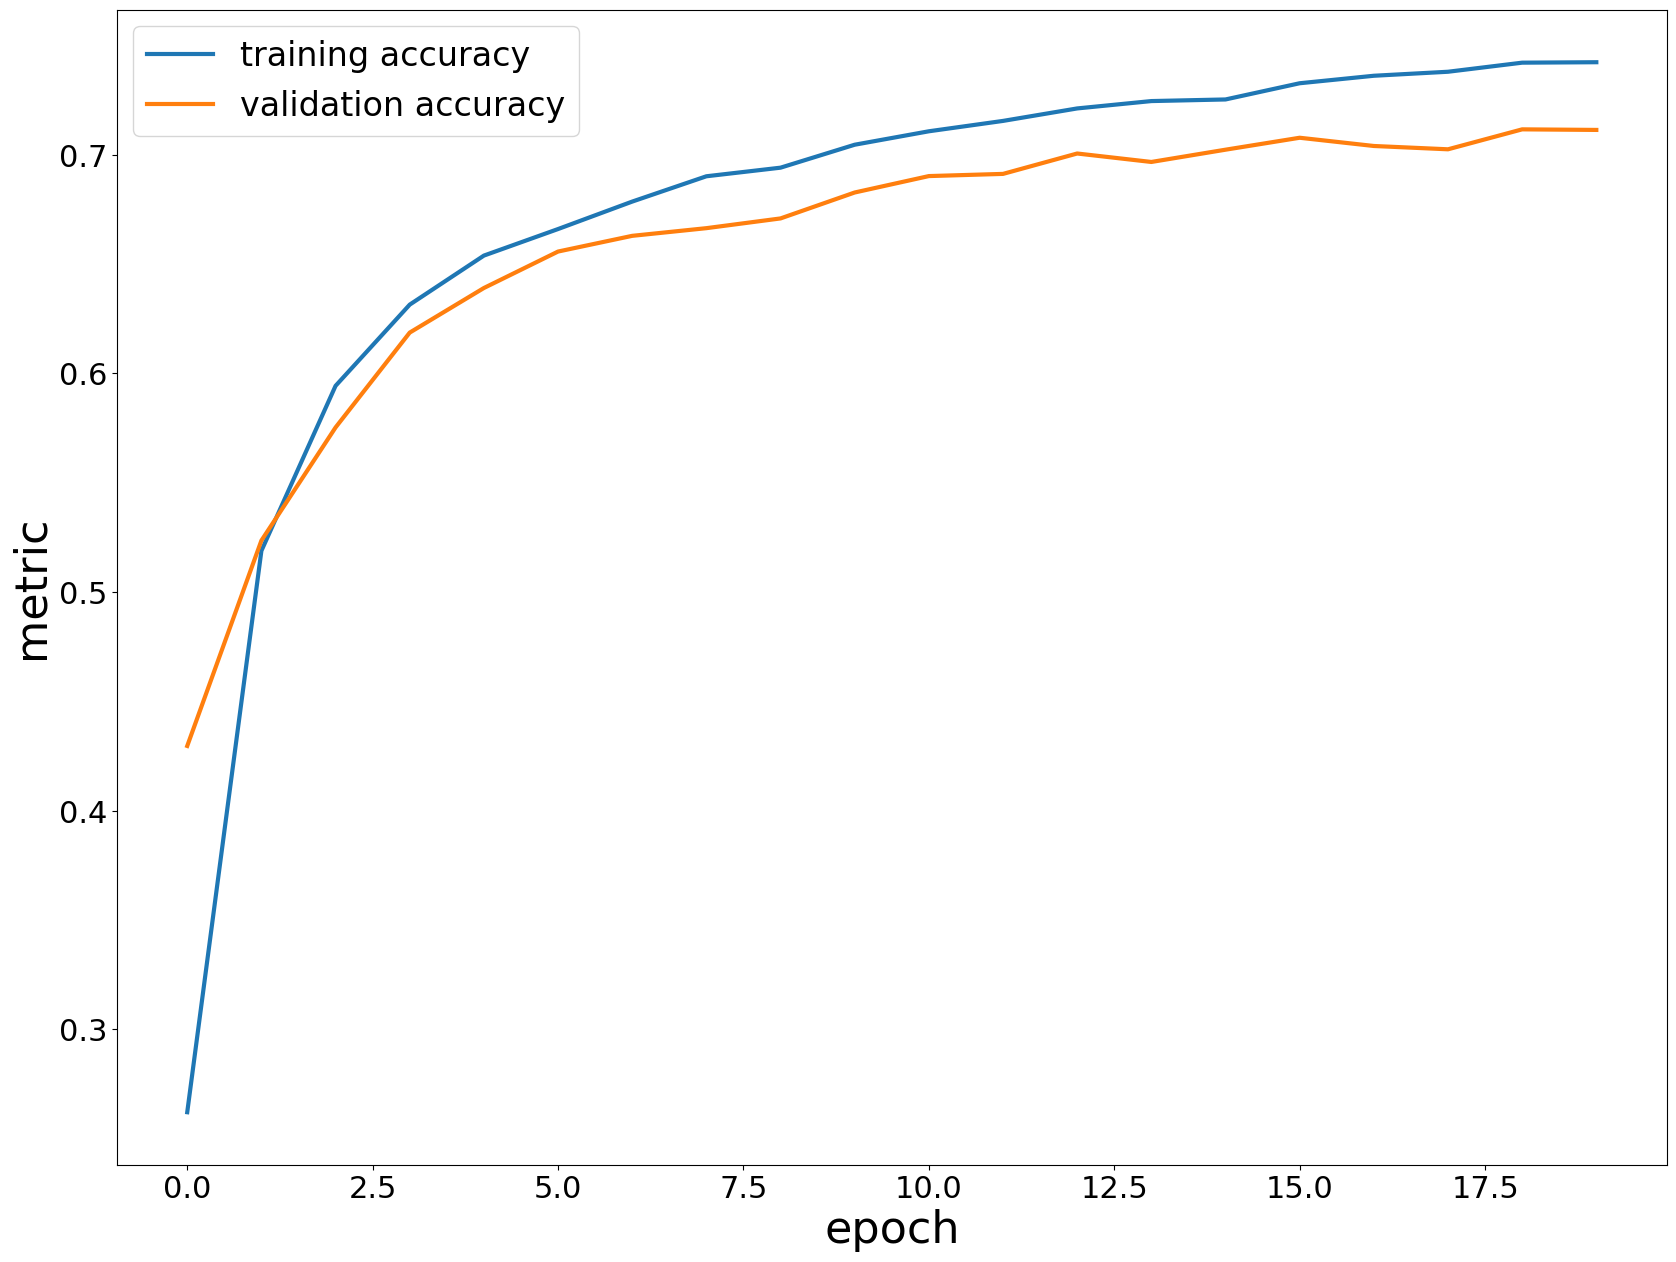

In [26]:
fig = plt.figure(figsize=(20, 15))
plt.xlabel('epoch')
plt.ylabel('metric')

ta = torch.mean(train_accs.reshape([n_epochs, -1]), axis=1).detach().cpu()
va = val_accs.detach().cpu()
plt.plot(ta, label="training accuracy")
plt.plot(va, label="validation accuracy")

plt.legend()

fig.savefig(f"outputs/stats/pass{vertex_pass}/{view}/stats_acc_{vertex_pass}_{view}.pdf", dpi=200)
fig.savefig(f"outputs/stats/pass{vertex_pass}/{view}/stats_acc_{vertex_pass}_{view}.png", dpi=200, facecolor='w')

In [27]:
with open(f'outputs/stats/pass{vertex_pass}/{view}/train_loss_{vertex_pass}_{view}_20.npy', 'wb') as f:
    np.save(f, tl)
with open(f'outputs/stats/pass{vertex_pass}/{view}/val_loss_{vertex_pass}_{view}_20.npy', 'wb') as f:
    np.save(f, vl)
with open(f'outputs/stats/pass{vertex_pass}/{view}/train_accs_{vertex_pass}_{view}_20.npy', 'wb') as f:
    np.save(f, ta)
with open(f'outputs/stats/pass{vertex_pass}/{view}/val_accs_{vertex_pass}_{view}_20.npy', 'wb') as f:
    np.save(f, va)

# Generating a TorchScript network

The network was trained on a GPU, but ultimately runs on a CPU in a C++ context. This means that the network must be converted to TorchScript format. This can be performed using the cell below and can be run at any time - it need not be run immediately after training the network, because it only requires access to a saved model state.

The only parameters requiring editing here are the location of the input file; which is the save model from the chosen training epoch (so some combination of the <code>moidel_name</code> and epoch with a <code>.pkl</code> extension), the <code>output_filename</code>, which should have a <code>.pt</code> extension, and also the number of classes <code>NUM_CLASSES</code>, which should, of course, match the previouslyt specified value.

The resultant <code>.pt</code> files are what will ultimately be loaded by Pandora for network inference.

In [ ]:
# This line is important for ensuring all tensors exist on the same device
torch.set_default_tensor_type(torch.FloatTensor)

filename = f"outputs/models/pass{vertex_pass}/{view}/dunefd_hd_accel_19.pkl"
output_filename = f"PandoraUnet_Vertex_DUNEFD_Accel_{vertex_pass}_{view}.pt"
the_seed = 42
device = torch.device('cpu')
NUM_CLASSES = 20

set_seed(the_seed)

model = load_model_only(filename, NUM_CLASSES, device)

sm = torch.jit.script(model)
sm.save(output_filename)

# Confusion Matrices

In [ ]:
# This line is important for GPU running, otherwise some weights end up on the CPU
torch.set_default_tensor_type(torch.cuda.FloatTensor)

view = "W"
vertex_pass = 1
the_seed = 42
gpu = torch.device('cuda:0')
batch_size=1
NUM_CLASSES = 20   # NULL = 0, various distance bands 1-19
image_path = f"Accel/Pass{vertex_pass}/Images{view}"

for subdir in ["models", "stats", "images"]:
    dir = f"outputs/{subdir}/pass{vertex_pass}/{view}"
    if not os.path.exists(dir):
        os.makedirs(dir)

set_seed(the_seed)
bunch = SegmentationBunch(image_path, "Hits", "Truth", batch_size=batch_size, valid_pct = 0.25, device=gpu)

filename = f"outputs/models/pass{vertex_pass}/{view}/dunefd_hd_accel_19.pkl"
NUM_CLASSES = 20

set_seed(the_seed)

model = load_model_only(filename, NUM_CLASSES, gpu)

In [ ]:
import scipy.stats as stats
binning = np.linspace(0, 20, 21, dtype=int)

model = model.to(gpu)
confusion = np.zeros((20,20))
for img, cls in bunch.valid_dl:
    img = img.to(gpu)
    output = model(img)
    _, preds = torch.max(output, 1)
    
    cls_detached = cls.cpu().numpy().flatten()
    preds_detached = preds.cpu().numpy().flatten()
    
    H, *_ = stats.binned_statistic_2d(preds_detached, cls_detached, None,
                                      bins=[binning, binning], statistic='count')
    confusion += H

In [ ]:
temporary = confusion.copy()
fig = plt.figure(figsize=(15, 10))
plt.xlabel('true class')
plt.ylabel('fraction')
plt.step(list(np.arange(1, 20)), np.sum(temporary[1:], axis=1) / np.sum(temporary[1:]), where="mid")

save_figure(fig, f"outputs/stats/pass{vertex_pass}/{view}/true_class_dist_{vertex_pass}_{view}")

In [ ]:
sums = np.sum(confusion, axis=1).repeat(20).reshape((20,20))
confusion /= sums

In [ ]:
print(f"--- Class Accuracy")
for t in range(confusion.shape[0]):
    print(f"{t:2}: {100*(confusion[t,t] / confusion[t].sum()):.1f}")
print()

In [ ]:
confusion[0,:] = 0
confusion[:,0] = 0

sums = np.sum(confusion, axis=1).repeat(20).reshape((20,20))
sums[0,:] = 1
confusion /= sums

print(f"--- Class Accuracy")
for t in range(confusion.shape[0]):
    print(f"{t:2}: {100*confusion[t,t]:.1f}")
print()

In [ ]:
fig = plt.figure(figsize=(15, 15))
plt.xlabel('truth')
plt.ylabel('network')
plt.imshow(confusion)
plt.colorbar()
save_figure(fig, f"outputs/stats/pass{vertex_pass}/{view}/confusion_{vertex_pass}_{view}")

for t in range(20):
    for n in range(20):
        print(f"{confusion[t, n]:.2f}", end=" ")
    print()

'test'